# Notebook 5 — Logistic Regression

**Sprint 7 — Machine Learning Fundamentals for AI/ML Engineers**

**Dataset:** Breast Cancer Wisconsin dataset (`sklearn.datasets.load_breast_cancer`) — 30 numeric measurements from cell nuclei, predicting whether a tumor is **malignant** or **benign**. Used consistently across Notebooks 3–6 as the classification dataset (Sprint 6 dataset was unavailable when preparing this notebook).

## Step 1 — Understand the Concept

### Classification
A supervised learning task where the target variable is **categorical** — the model predicts which discrete class (or category) a data point belongs to, rather than a continuous number.

### Binary Classification
Classification with exactly two possible classes (e.g., malignant vs benign, spam vs not-spam, fraud vs not-fraud).

### Why is Logistic Regression a classification algorithm despite its name?
Despite the name "regression," Logistic Regression does **not** predict a continuous numeric target — it predicts the **probability** that a data point belongs to a particular class, and that probability is then converted into a class label using a threshold. The name is historical: it builds directly on linear regression's linear combination of features (`b0 + b1*x1 + ...`), but instead of using that value as the prediction itself, it squashes it through the **sigmoid function** to constrain the output to a valid probability between 0 and 1, then treats that as a classification decision. Because the final output is a class label, not a number on an open-ended scale, it belongs to the classification family of algorithms.

### The Sigmoid Function
`sigmoid(z) = 1 / (1 + e^(-z))`, where `z = b0 + b1*x1 + b2*x2 + ... + bn*xn` (the same linear combination as linear regression).

The sigmoid function takes any real number (from -∞ to +∞) and maps it to a value strictly between 0 and 1 — perfect for representing a probability. Very negative `z` → probability near 0. Very positive `z` → probability near 1. `z = 0` → probability exactly 0.5.

### Probability
Logistic Regression outputs `P(y=1 | X)` — the probability that a given row belongs to the "positive" class (e.g., malignant), given its feature values.

### Decision Boundary
The boundary in feature space where the model is exactly 50/50 (i.e., where `z = 0`, so `sigmoid(z) = 0.5`). On one side of this boundary the model predicts class 0; on the other, class 1.

### Threshold
The probability cutoff used to convert a predicted probability into a class label. The default is 0.5 (probability ≥ 0.5 → predict class 1), but this can be adjusted depending on the business cost of false positives vs false negatives (e.g., in medical screening you might lower the threshold to catch more true positives, accepting more false alarms).

### Log Loss (Binary Cross-Entropy)
The cost function Logistic Regression minimizes during training:

`Log Loss = -(1/n) * sum( y*log(p) + (1-y)*log(1-p) )`

It heavily penalizes confident-but-wrong predictions (e.g., predicting 0.99 probability for a class that turns out to be the opposite) far more than a cautious wrong prediction near 0.5. This is why it is preferred over plain squared error for classification.

### Coefficients
Just like linear regression, each feature gets a learned coefficient. However, interpretation is different: a positive coefficient means that increasing that feature increases the **log-odds** of the positive class (and therefore its predicted probability), holding other features constant.

### Multiclass Classification
Logistic Regression can be extended beyond two classes using strategies like **One-vs-Rest** (train one binary classifier per class, "this class vs all others") or **multinomial/softmax** logistic regression (a direct generalization of the sigmoid to multiple classes at once). scikit-learn handles this automatically when the target has more than two classes.

### Assumptions
- A (roughly) linear relationship between the features and the **log-odds** of the outcome (not the raw probability itself).
- Observations are independent of each other.
- Limited multicollinearity among features.
- Requires a reasonably large sample size relative to the number of features for stable coefficient estimates.

### When to use it
- The target is binary (or multiclass) categorical.
- You want a model whose predictions are naturally interpretable as probabilities.
- You want a fast, simple, well-calibrated baseline before trying more complex classifiers.

### When not to use it
- The true decision boundary is strongly non-linear and no feature engineering (polynomial features, interactions) is applied.
- Classes are not linearly separable at all in the given feature space.

## Step 2 — Demonstrate the Concept

**Simple example:** Predicting whether a student passes or fails an exam based on hours studied. As study hours increase, the *probability* of passing increases, following an S-shaped (sigmoid) curve rather than a straight line — probability can't exceed 1 or drop below 0, which is exactly what the sigmoid guarantees and a straight line does not.

**Mathematical intuition:** A straight line can shoot off to +∞ or -∞, which makes no sense as a probability. The sigmoid function takes that unbounded line and "folds" it into the 0–1 range, so extreme feature values produce probabilities that approach — but never quite reach — 0 or 1.

**Real-world example:** Predicting whether a bank loan applicant will default, based on income, credit history, and existing debt.

**Business example:** Predicting whether a customer will churn (cancel a subscription) next month based on usage patterns, so the business can proactively intervene with the highest-risk customers.

**AI/ML use case (our dataset):** Predicting whether a breast tumor is malignant or benign from measurements of cell nuclei — a genuinely high-stakes classification task where understanding *both* the prediction and its confidence (probability) matters.

## Step 3 — Implement the Concept (Python)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

np.random.seed(42)

cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target   # 0 = malignant, 1 = benign (per sklearn's encoding)

print("Target names:", cancer.target_names)
print("Class balance:\n", y.value_counts())

Target names: ['malignant' 'benign']
Class balance:
 target
1    357
0    212
Name: count, dtype: int64


In [2]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 3.1 Train/Test split, then scale (fit scaler on TRAIN only — no leakage)

Logistic Regression's optimizer converges faster and more reliably when features are on comparable scales.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


### 3.2 Fit Logistic Regression

In [4]:
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]   # probability of class "1" (benign)

print("First 10 predicted probabilities (class=1/benign):", np.round(y_proba[:10], 3))
print("First 10 predicted labels:                        ", y_pred[:10])
print("First 10 actual labels:                            ", y_test.values[:10])

First 10 predicted probabilities (class=1/benign): [0.    1.    0.006 0.534 0.    0.992 1.    0.    0.    0.   ]
First 10 predicted labels:                         [0 1 0 1 0 1 1 0 0 0]
First 10 actual labels:                             [0 1 0 1 0 1 1 0 0 0]


### 3.3 Visualizing the Sigmoid Function

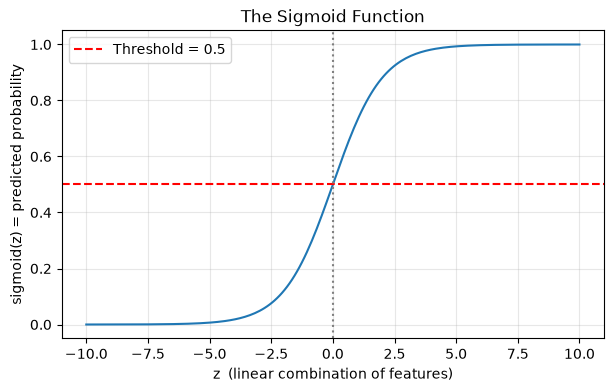

In [5]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid)
plt.axhline(0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.axvline(0, color='gray', linestyle=':')
plt.xlabel('z  (linear combination of features)')
plt.ylabel('sigmoid(z) = predicted probability')
plt.title('The Sigmoid Function')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 3.4 Coefficients — which features push predictions toward malignant vs benign?

In [6]:
coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_table.head(10).to_string(index=False))

             feature  coefficient
       worst texture    -1.255088
        radius error    -1.082965
worst concave points    -0.953686
          worst area    -0.947756
        worst radius    -0.947616
      worst symmetry    -0.939181
          area error    -0.929104
     worst concavity    -0.823151
     worst perimeter    -0.763220
    worst smoothness    -0.746625


### 3.5 Confusion Matrix and Classification Metrics

In [7]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Confusion Matrix:
[[41  1]
 [ 1 71]]

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



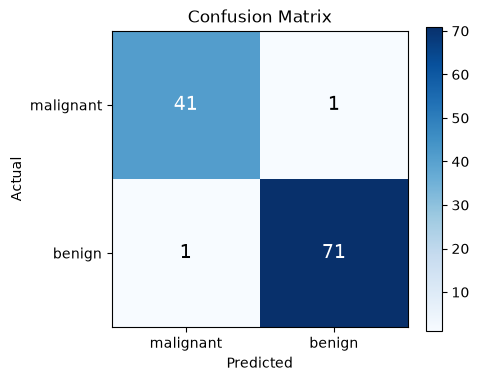

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(cancer.target_names)
ax.set_yticks([0, 1]); ax.set_yticklabels(cancer.target_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

### 3.6 Effect of changing the Threshold

In [9]:
thresholds_to_try = [0.3, 0.5, 0.7]

for t in thresholds_to_try:
    preds_at_t = (y_proba >= t).astype(int)
    prec = precision_score(y_test, preds_at_t)
    rec = recall_score(y_test, preds_at_t)
    print(f"Threshold={t} -> Precision: {prec:.3f}  Recall: {rec:.3f}")

Threshold=0.3 -> Precision: 0.973  Recall: 1.000
Threshold=0.5 -> Precision: 0.986  Recall: 0.986
Threshold=0.7 -> Precision: 0.985  Recall: 0.931


### 3.7 ROC Curve and AUC

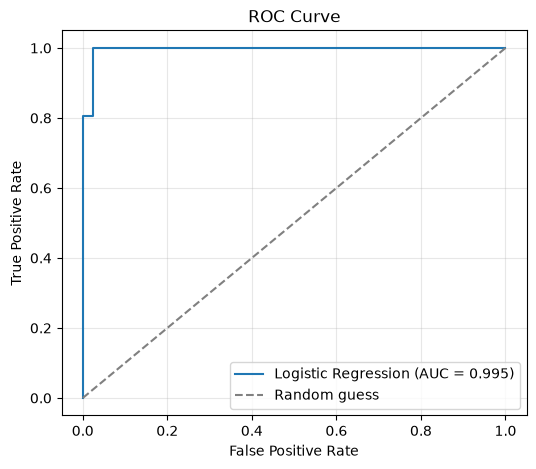

AUC: 0.9954


In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC: {auc:.4f}")

### 3.8 Log Loss implemented manually with NumPy

In [11]:
def log_loss_manual(y_true, y_pred_proba, eps=1e-15):
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)  # avoid log(0)
    return -np.mean(
        y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba)
    )

manual_loss = log_loss_manual(y_test.values, y_proba)

from sklearn.metrics import log_loss
sklearn_loss = log_loss(y_test, y_proba)

print(f"Manually computed log loss : {manual_loss:.4f}")
print(f"scikit-learn's log_loss    : {sklearn_loss:.4f}")

Manually computed log loss : 0.0777
scikit-learn's log_loss    : 0.0777


In [12]:
# Illustrate WHY log loss punishes confident-wrong predictions harshly
example_true = 1
for confident_wrong_proba in [0.5, 0.3, 0.1, 0.01]:
    loss = -np.log(confident_wrong_proba)
    print(f"True label=1, predicted probability={confident_wrong_proba:<5} -> loss contribution: {loss:.3f}")

True label=1, predicted probability=0.5   -> loss contribution: 0.693
True label=1, predicted probability=0.3   -> loss contribution: 1.204
True label=1, predicted probability=0.1   -> loss contribution: 2.303
True label=1, predicted probability=0.01  -> loss contribution: 4.605


## Step 4 — Interpret the Result

**What the model learned:** Logistic Regression learned a coefficient for each of the 30 cell-measurement features, representing how strongly (and in which direction) each feature shifts the log-odds of a tumor being **benign** (since class "1" = benign in scikit-learn's encoding for this dataset). Features with large positive coefficients push predictions toward benign; large negative coefficients push toward malignant.

**What the confusion matrix tells us:** It breaks predictions into four buckets — True Positives, True Negatives, False Positives, and False Negatives. In a medical context, a **False Negative** (model predicts benign, but the tumor is actually malignant) is far more dangerous than a False Positive (predicts malignant, but it's actually benign) — the former means a real cancer could go unflagged, while the latter just leads to extra testing. This is exactly why we don't stop at accuracy.

**Why accuracy alone is not sufficient here:** If, say, 90% of tumors in a dataset were benign, a model that *always* predicts "benign" would score 90% accuracy while being clinically useless — it would miss every single malignant case. **Precision**, **Recall**, and **F1** give a much more honest picture:
- **Precision** (of predicted-malignant cases, how many really are malignant) matters when false alarms are costly.
- **Recall** (of actually-malignant cases, how many did we catch) matters when missing a case is dangerous — in this medical scenario, recall on the malignant class is usually the metric to prioritize.
- **F1** balances the two when neither can be ignored.

**On the threshold experiment:** Lowering the classification threshold below 0.5 makes the model flag more cases as the positive class, typically **increasing recall** (catching more true positives) at the cost of **decreasing precision** (more false alarms). Raising the threshold does the opposite. In a cancer-screening context, a clinician might deliberately lower the threshold for flagging "malignant" to avoid missing real cases, accepting more follow-up tests on benign patients as an acceptable trade-off.

**On the ROC curve and AUC:** The AUC score summarizes the model's ability to separate the two classes across *all* possible thresholds at once — an AUC close to 1.0 (as we see here) means the model assigns higher malignancy probability to malignant cases than to benign ones almost all of the time, regardless of where exactly we set the cutoff. An AUC of 0.5 would mean the model is no better than random guessing.

**On log loss:** Unlike accuracy, log loss cares about *how confident* the wrong predictions were. The manual demonstration shows that a wrong prediction made with 99% confidence is penalized far more heavily than a wrong prediction made near 50/50 — which is exactly the behavior we want from a probabilistic model: being uncertain and wrong should cost less than being confidently and badly wrong.